# The customer, end to end

The question is whether `Churn` is `Yes`. The file has 7043 customers, and 1869 leave, a rate of $1869/7043$. Predicting Stay scores $5174/7043$ and flags none of those 1869.

The contract rates on all 7043 rows are $331/775$ month-to-month, $166/1473$ one year, and $16/565$ two year. Tenure from 1 to 12 months leaves at $1037/2175$. Fiber optic leaves at $1297/3096$, and a two-year fiber customer leaves at $31/429$.

The fit set is every customer whose MD5 digest is not divisible by 5: 5626 people. On a menu of eight sentences, the winner is month-to-month and (fiber optic or electronic check), with fit $F_1 = 2246/3679$.

On the other 1417 people the counts are $tp = 244$, $fp = 252$, $fn = 121$, $tn = 800$. So $F_1 = 488/861$. Held-out accuracy is $1044/1417$, and Stay-for-everyone scores $1052/1417$.

A one-coefficient logistic model on the fit contracts has probabilities $674/1555$ and $39/629$. Both are below $1/2$, so a cut at one half flags nobody.

`9305-CDSKC` is a held-out leave the sentence flags. `3668-QPYBK` is a held-out leave it misses.


In [1]:
# Locate the telco table beside this notebook, or under the course root.
import csv
from pathlib import Path

def data_path():
    here = Path.cwd()
    name = "Telco-Customer-Churn.csv"
    for folder in [here, *here.parents]:
        nested = folder / "17-Customer Churn" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists():
            return direct
    raise FileNotFoundError(name)

def read_customers():
    with data_path().open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))
# The headline counts, recomputed from the file.
import hashlib
from fractions import Fraction

rows = read_customers()

def held(customer_id):
    digest = hashlib.md5(customer_id.encode("utf-8")).hexdigest()
    return int(digest, 16) % 5 == 0

def leave_rule(row):
    return row["Contract"] == "Month-to-month" and (
        row["InternetService"] == "Fiber optic"
        or row["PaymentMethod"] == "Electronic check"
    )

left = sum(row["Churn"] == "Yes" for row in rows)
assert len(rows) == 7043 and left == 1869
assert Fraction(left, 7043) == Fraction(1869, 7043)
test = [row for row in rows if held(row["customerID"])]
assert len(test) == 1417
tp = sum(leave_rule(row) and row["Churn"] == "Yes" for row in test)
fp = sum(leave_rule(row) and row["Churn"] == "No" for row in test)
fn = sum((not leave_rule(row)) and row["Churn"] == "Yes" for row in test)
tn = sum((not leave_rule(row)) and row["Churn"] == "No" for row in test)
precision = Fraction(tp, tp + fp)
recall = Fraction(tp, tp + fn)
f1 = 2 * precision * recall / (precision + recall)
print(tp, fp, fn, tn, f1)
assert (tp, fp, fn, tn) == (244, 252, 121, 800)
assert f1 == Fraction(488, 861)
assert Fraction(1044, 1417) < Fraction(1052, 1417)


244 252 121 800 488/861


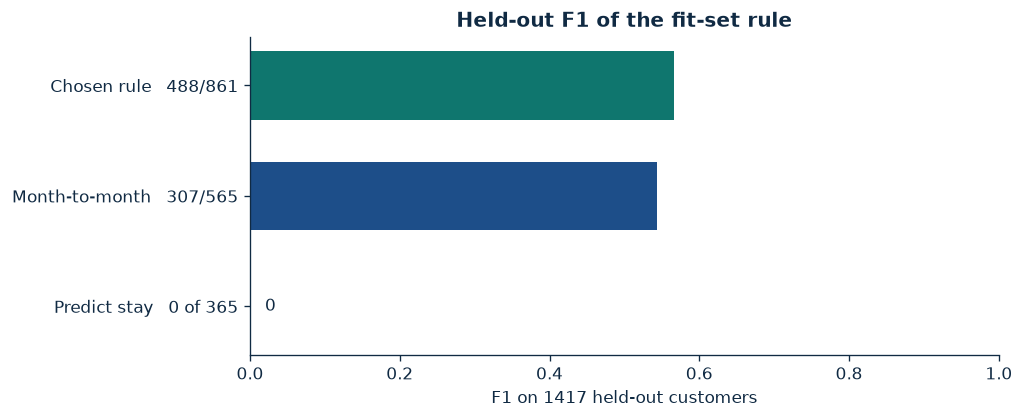

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
    "axes.titlecolor": "#102a43",
})
# Same held-out chart as lesson 11.
from fractions import Fraction
labels = [
    "Chosen rule   488/861",
    "Month-to-month   307/565",
    "Predict stay   0 of 365",
]
scores = [float(Fraction(488, 861)), float(Fraction(307, 565)), 0.0]
colors = ["#0f766e", "#1d4e89", "#c2410c"]
positions = [2, 1, 0]
figure, axis = plt.subplots(figsize=(8.6, 3.6))
axis.barh(positions, scores, color=colors, height=0.62)
axis.set_yticks(positions, labels)
axis.set_xlim(0, 1)
axis.text(0.02, 0, "0", va="center", color="#102a43")
axis.set_xlabel("F1 on 1417 held-out customers")
axis.set_title("Held-out F1 of the fit-set rule")
figure.tight_layout()


## Pitfall

The green bar and the blue bar are close: $488/861$ against $307/565$. The clay bar is the accuracy champion of the holdout, and its $F_1$ is drawn as 0. Closeness of the two positive bars is the result. Stretching the axis to start at 0.5 would invent a wider gap.

## Summary

1869 of 7043 customers leave. The reported rule is month-to-month and (fiber optic or electronic check). Its held-out $F_1$ is $488/861$.
